# Mapping Outlier Points in Accumulated Data to Raw Measurements

In [222]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from venus_ml import VenusDataset

## Initialize Both Datasets

In [223]:
outliers = ["g28_fw", "ext_i", "puller_v", "fcv1_i", "extraction_v"]
sets = ['00', '01', '02', '03', '04', '05', '06', '08', '08a', '08b', '08c', '08d', '09', '10', '10b', '11', '11b', '12', '13', '14']

acc_data_set_config = {
    "file_path": "../data/all_stabilties_settled_watch_data.parquet",
    "input_columns": [out + "_mean" for out in outliers] + ["run_id", "unix_time"],
    "output_columns": [],

}

raw_data_set_config = {
    "file_path": "../data/raw_watch_data.parquet",
    "input_columns": outliers + ["run_id", "unix_time", "accumulation_group"],
    "output_columns": [],

}

accumulated = VenusDataset(**acc_data_set_config)
raw = VenusDataset(**raw_data_set_config)

In [224]:
for set in sets:
    print("_________________")
    print(f"Set {set}")
    print("Acc groups: ", accumulated.inputs[accumulated.inputs["run_id"] == set].shape[0])
    zero = raw.inputs[raw.inputs["run_id"] == set]
    print("Raw acc groups: ", zero["accumulation_group"].shape[0]//60)

_________________
Set 00
Acc groups:  3696
Raw acc groups:  3696
_________________
Set 01
Acc groups:  819
Raw acc groups:  819
_________________
Set 02
Acc groups:  1617
Raw acc groups:  1617
_________________
Set 03
Acc groups:  410
Raw acc groups:  410
_________________
Set 04
Acc groups:  20
Raw acc groups:  20
_________________
Set 05
Acc groups:  525
Raw acc groups:  525
_________________
Set 06
Acc groups:  1239
Raw acc groups:  1239
_________________
Set 08
Acc groups:  10888
Raw acc groups:  10888
_________________
Set 08a
Acc groups:  1732
Raw acc groups:  1732
_________________
Set 08b
Acc groups:  1827
Raw acc groups:  1827
_________________
Set 08c
Acc groups:  2856
Raw acc groups:  2856
_________________
Set 08d
Acc groups:  4473
Raw acc groups:  4473
_________________
Set 09
Acc groups:  651
Raw acc groups:  651
_________________
Set 10
Acc groups:  357
Raw acc groups:  357
_________________
Set 10b
Acc groups:  1113
Raw acc groups:  1113
_________________
Set 11
Acc gro

In [225]:
def split_by_set(dataset, feature):
    grouped_data = dataset.inputs.groupby('run_id')[feature].apply(lambda x: np.array(x)).to_dict()
    return grouped_data

def plot_over_time(df, feature, run, std_thresh=2):
    std_dev = df[feature].std()
    overall_mean = df[feature].mean()
    one_std_above = overall_mean + std_thresh*std_dev
    one_std_below = overall_mean - std_thresh*std_dev
    
    df = df.loc[df['run_id'] == run, [feature, 'unix_time']]
    x_axis = df['unix_time']
    y_axis = df[feature]
    plt.figure(figsize=(5, 5))
    plt.scatter(x=x_axis, y=y_axis)
    plt.axhline(y=one_std_above, color='blue', linestyle=':', label='1 Std Dev Above')
    plt.axhline(y=one_std_below, color='blue', linestyle=':', label='1 Std Dev Below')
    plt.title(f'Scatter Plot of {feature} Over Set {run}')
    plt.xlabel('Unix Time')
    plt.ylabel(f"{feature} value")
    plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)
    plt.gca().get_xaxis().get_major_formatter().set_useOffset(False)
    plt.tight_layout()
    
    plt.show()

# Plot Accumulated Set/Features with Previously Observed Outliers

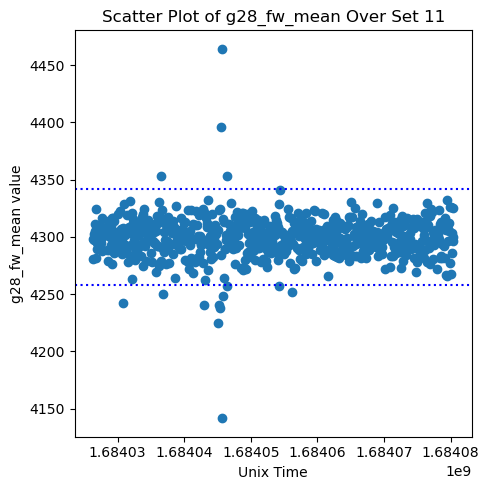

In [226]:
acc_df = accumulated.inputs
plot_over_time(acc_df, "g28_fw_mean", "11", std_thresh=5)

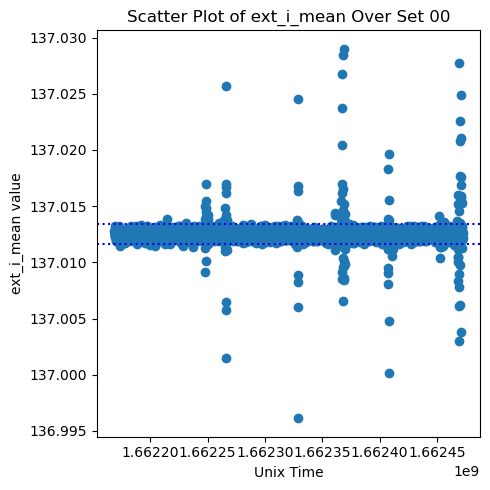

In [227]:
plot_over_time(acc_df, "ext_i_mean", "00")

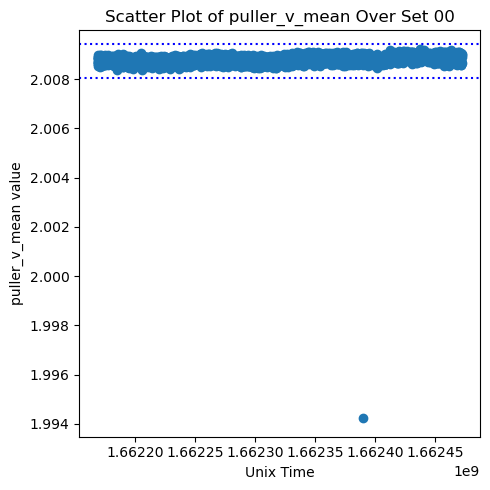

In [228]:
plot_over_time(acc_df, "puller_v_mean", "00")

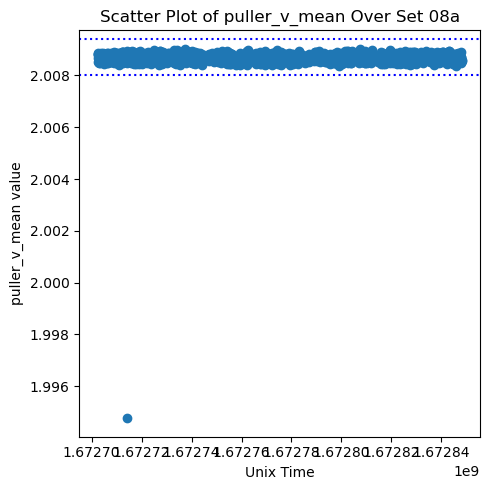

In [229]:
plot_over_time(acc_df, "puller_v_mean", "08a")

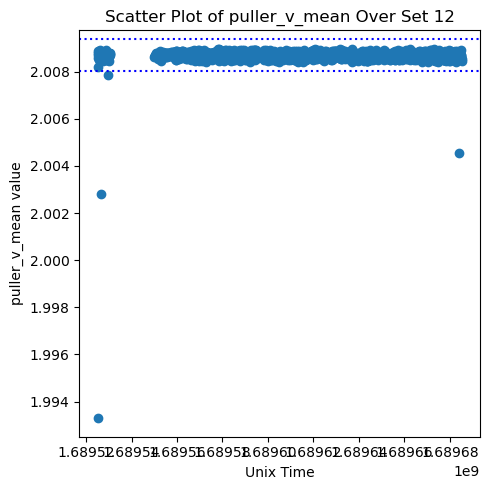

In [230]:
plot_over_time(acc_df, "puller_v_mean", "12")

## Scan and Identify Specific Accumulated Outlier Points 

In [231]:
def filter_by_std_dev(df, column_name, std_dev_threshold, run_id):
    # Filter the dataframe by the run_id
    run_df = df[df['run_id'] == run_id].reset_index(drop=True)
    
    if run_df.empty:
        raise ValueError(f"No data found for run_id '{run_id}'")
    
    if not np.issubdtype(run_df[column_name].dtype, np.number):
        raise TypeError(f"The column '{column_name}' must contain numeric data.")
    
    mean_value = run_df[column_name].mean()
    std_dev_value = run_df[column_name].std()  # Using the overall std_dev as per the requirement
    
    lower_bound = mean_value - std_dev_threshold * std_dev_value
    upper_bound = mean_value + std_dev_threshold * std_dev_value
    
    filtered_df = run_df[(run_df[column_name] < lower_bound) | (run_df[column_name] > upper_bound)]
    
    return filtered_df

def count_unique_values(df, column_name):
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' does not exist in the dataframe.")
    
    unique_counts = df[column_name].value_counts()
    
    return unique_counts

def filter_by_run_id_and_accumulation_group(df, run_id, accumulation_group):
    if 'run_id' not in df.columns:
        raise ValueError("The dataframe does not contain the column 'run_id'")
    if 'accumulation_group' not in df.columns:
        raise ValueError("The dataframe does not contain the column 'accumulation_group'")
    filtered_df = df[(df['run_id'] == run_id) & (df['accumulation_group'] == accumulation_group)]
    
    return filtered_df

In [232]:
result = filter_by_std_dev(acc_df, "puller_v_mean", 3, "12")
result

,unix_time,fcv1_i_mean,ext_i_mean,g28_fw_mean,extraction_v_mean,puller_v_mean,run_id
3,1.689525e+09,0.000669,137.012133,4299.266667,19.991392,1.993295,12
20,1.689527e+09,0.000689,137.012600,4302.733333,19.991298,2.002804,12
1708,1.689684e+09,0.000763,137.012933,4303.583333,19.991353,2.004564,12


In [233]:
group = filter_by_run_id_and_accumulation_group(raw.inputs, "00", 2692)
group

,accumulation_group,fcv1_in,fcv1_i,ext_i,g28_fw,extraction_v,puller_v,ext_i_set,extraction_v_set,puller_v_set,run_id
161520,2692,1.0,0.000255,137.015,4302.0,19.9899,2.00874,137.012,2048.0,546.0,00
161521,2692,1.0,0.000259,137.007,4301.0,19.9911,2.00874,137.012,2048.0,546.0,00
161522,2692,1.0,0.000253,137.015,4301.0,19.9918,1.14631,137.012,2048.0,546.0,00
161523,2692,1.0,0.000254,137.015,4300.0,19.9918,2.00921,137.012,2048.0,546.0,00
161524,2692,1.0,0.000253,137.015,4304.0,19.9918,2.00827,137.012,2048.0,546.0,00
161525,2692,1.0,0.000253,137.015,4304.0,19.9911,2.00921,137.012,2048.0,546.0,00
161526,2692,1.0,0.000254,137.011,4295.0,19.9930,2.00874,137.012,2048.0,546.0,00
161527,2692,1.0,0.000254,137.015,4295.0,19.9918,2.00874,137.012,2048.0,546.0,00
161528,2692,1.0,0.000253,137.011,4295.0,19.9911,2.00874,137.012,2048.0,546.0,00
161529,2692,1.0,0.000253,137.011,4293.0,19.9911,2.00874,137.012,2048.0,546.0,00


## Get outlier accumulation groups 

In [234]:
def get_outlier_indexes(outlier_group):
    return outlier_group.index.tolist()

In [235]:
outliers = [
    {"column": "g28_fw_mean",
     "set": ["11"],},
    {"column": "puller_v_mean",
     "set": ["00", "08a", "12"],},
    {"column": "ext_i_mean",
     "set": ["00"],},
]


raw_config = {
    "file_path": "../data/raw_watch_data.parquet",
    "input_columns": ['inj_mbar', 'k18_ref', 'x_ray_source', 'x_ray_exit', 'bias_i', 'bias_v', 'extraction_i', 'k18_fw', 'g28_fw', 'inj_i', 'ext_i', 'mid_i', 'sext_i', 'extraction_v', 'puller_v', 'run_id', 'unix_time', 'accumulation_group', 'time'],
    "output_columns": [],

}
raw_data = VenusDataset(**raw_config)
print(raw_data.inputs.columns)

Index(['accumulation_group', 'time', 'inj_i', 'ext_i', 'mid_i', 'sext_i',
       'inj_mbar', 'bias_v', 'bias_i', 'k18_fw', 'k18_ref', 'g28_fw',
       'x_ray_source', 'x_ray_exit', 'extraction_v', 'extraction_i',
       'puller_v', 'inj_i_set', 'ext_i_set', 'mid_i_set', 'sext_i_set',
       'k18_fw_set', 'extraction_v_set', 'puller_v_set', 'run_id'],
      dtype='object')


In [249]:
def process_outliers(outliers, accumulated_df, raw_df):
    """
    Processes the list of outliers, retrieves corresponding raw data, and organizes the results.

    Args:
        outliers (List[Dict]): A list of dictionaries specifying columns and run_ids with outliers.
        accumulated_df (pd.DataFrame): The accumulated dataframe.
        raw_df (pd.DataFrame): The raw dataframe.

    Returns:
        Dict: A nested dictionary grouped by column and run_id containing raw data for outlier points.
    """
    results = {}

    for outlier in outliers:
        column_name = outlier['column']
        run_ids = outlier['set']

        # Initialize a nested dictionary for this column
        results[column_name] = {}

        for run_id in run_ids:
            # Call filter_by_std_dev to get the outliers for this column and run_id
            outlier_group = filter_by_std_dev(accumulated_df, column_name, std_dev_threshold=3, run_id=run_id)
            # Get the accumulation groups (indexes) of the outliers
            accumulation_groups = get_outlier_indexes(outlier_group)

            # Initialize a list to hold raw data for each accumulation group
            raw_data_list = []
            for accumulation_group in accumulation_groups:
                # Call filter_by_run_id_and_accumulation_group for each accumulation group
                group_data = filter_by_run_id_and_accumulation_group(raw_df, run_id, accumulation_group)
                raw_data_list.append(group_data)

            # Concatenate the raw data for all accumulation groups
            if raw_data_list:
                raw_data_concatenated = pd.concat(raw_data_list, ignore_index=True)
            else:
                raw_data_concatenated = pd.DataFrame()
                print(f"No raw data found for the outlier accumulation groups in run_id '{run_id}'.")
            
            # Store the raw data in the results dictionary
            results[column_name][run_id] = raw_data_concatenated

    return results

from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import parallel_coordinates

def parallel_coords(outlier_data, outlier_feature, run_id, accumulation_group):
    """
    Plots a parallel coordinates plot for the specified accumulation group within the outlier data,
    normalizing feature values to address scale differences.

    Args:
        outlier_data (dict): Nested dictionary with the structure outlier_data[outlier_feature][run_id] = DataFrame.
        outlier_feature (str): The feature that had outliers.
        run_id (str): The run ID to consider.
        accumulation_group (int): The accumulation group to visualize.
    """
    # Check if the outlier_feature and run_id are in the outlier_data
    if outlier_feature not in outlier_data:
        print(f"Outlier feature '{outlier_feature}' not found in outlier_data.")
        return
    if run_id not in outlier_data[outlier_feature]:
        print(f"Run ID '{run_id}' not found for outlier feature '{outlier_feature}'.")
        return

    # Get the DataFrame for the specified outlier_feature and run_id
    data = outlier_data[outlier_feature][run_id]

    # Filter the data for the specified accumulation_group
    group_data = data[data['accumulation_group'] == accumulation_group]
    if group_data.empty:
        print(f"No data found for accumulation_group '{accumulation_group}' in run_id '{run_id}' for feature '{outlier_feature}'.")
        return

    # Prepare the data for parallel coordinates plot
    # Exclude non-feature columns
    exclude_columns = ['run_id', 'accumulation_group', 'status', 'unix_time']
    # Optionally, exclude the outlier_feature itself if desired
    # exclude_columns.append(outlier_feature)

    feature_columns = [col for col in group_data.columns if col not in exclude_columns]
    # Ensure that the data contains more than one feature to plot
    if len(feature_columns) < 2:
        print("Not enough features to plot parallel coordinates.")
        return

    # Normalize the feature columns using Min-Max scaling
    scaler = MinMaxScaler()
    group_data_normalized = group_data.copy()
    group_data_normalized[feature_columns] = scaler.fit_transform(group_data[feature_columns])

    # Reset the index and add a 'sample' column to differentiate the measurements
    group_data_normalized = group_data_normalized.reset_index(drop=True)
    group_data_normalized['sample'] = group_data_normalized.index.astype(str)  # Convert index to string for plotting

    # Prepare the DataFrame for plotting
    plot_data = group_data_normalized[['sample'] + feature_columns]

    # Plot the parallel coordinates
    plt.figure(figsize=(12, 6))
    parallel_coordinates(plot_data, 'sample', colormap=plt.cm.Set1)
    plt.title(f'Parallel Coordinates Plot for Run ID {run_id}, Accumulation Group {accumulation_group}')
    plt.xlabel('Features')
    plt.ylabel('Normalized Values')
    plt.legend([], [])  # Remove legend to prevent clutter

    # Rotate x-axis labels to prevent overlap
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels

    plt.show()
    

def plot_features_over_time(outlier_data, outlier_feature, run_id, accumulation_group, features_to_plot):
    # Check if the outlier_feature and run_id are in the outlier_data
    if outlier_feature not in outlier_data:
        print(f"Outlier feature '{outlier_feature}' not found in outlier_data.")
        return
    if run_id not in outlier_data[outlier_feature]:
        print(f"Run ID '{run_id}' not found for outlier feature '{outlier_feature}'.")
        return

    # Get the DataFrame for the specified outlier_feature and run_id
    data = outlier_data[outlier_feature][run_id]

    # Filter the data for the specified accumulation_group
    group_data = data[data['accumulation_group'] == accumulation_group]
    if group_data.empty:
        print(f"No data found for accumulation_group '{accumulation_group}' in run_id '{run_id}' for feature '{outlier_feature}'.")
        return

    # Check if the features_to_plot exist in the DataFrame
    missing_features = [feature for feature in features_to_plot if feature not in group_data.columns]
    if missing_features:
        print(f"The following features were not found in the data: {missing_features}")
        return

    # Check if 'unix_time' or a time column exists
    if 'unix_time' in group_data.columns:
        # Ensure 'unix_time' is in datetime format
        if not pd.api.types.is_datetime64_any_dtype(group_data['unix_time']):
            group_data['unix_time'] = pd.to_datetime(group_data['unix_time'], unit='s')
        time_column = 'unix_time'
    elif 'time' in group_data.columns:
        time_column = 'time'
    elif 'measurement_index' in group_data.columns:
        time_column = 'measurement_index'
    else:
        print("No time column found in the data. Cannot plot over time.")
        return

    # Sort the data by time
    group_data = group_data.sort_values(by=time_column)
    
    from sklearn.preprocessing import MinMaxScaler  # Make sure this import is at the top of your script
    scaler = MinMaxScaler()
    group_data[features_to_plot] = scaler.fit_transform(group_data[features_to_plot])

    # Plot the features over time
    plt.figure(figsize=(12, 6))
    for feature in features_to_plot:
        plt.plot(group_data[time_column], group_data[feature], linestyle='-', label=feature)

    plt.title(f"Features Over Time\nRun ID: {run_id}, Accumulation Group: {accumulation_group}")
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

In [237]:
raw_outlier_data = process_outliers(outliers, acc_df, raw_data.inputs)

In [238]:
raw_outlier_data["g28_fw_mean"]["11"]

,accumulation_group,time,inj_i,ext_i,mid_i,sext_i,inj_mbar,bias_v,bias_i,k18_fw,...,extraction_i,puller_v,inj_i_set,ext_i_set,mid_i_set,sext_i_set,k18_fw_set,extraction_v_set,puller_v_set,run_id
0,57,1.684031e+09,185.000,137.015,152.988,430.004,9.577780e-08,61.3117,5.50554,1400.0,...,6.83187,2.00921,185.0,137.012,152.988,430.0,0.0,2048.0,546.0,11
1,57,1.684031e+09,184.996,137.011,152.984,429.996,9.911130e-08,61.3117,5.31785,1397.0,...,6.59820,2.00874,185.0,137.012,152.988,430.0,0.0,2048.0,546.0,11
2,57,1.684031e+09,185.000,137.011,152.988,429.989,9.457820e-08,61.3117,3.12815,1397.0,...,5.53213,2.00874,185.0,137.012,152.988,430.0,0.0,2048.0,546.0,11
3,57,1.684031e+09,185.000,137.015,152.988,429.996,9.479140e-08,61.3117,3.22199,1399.0,...,5.54527,2.00874,185.0,137.012,152.988,430.0,0.0,2048.0,546.0,11
4,57,1.684031e+09,185.000,137.015,152.991,429.996,9.534760e-08,61.3117,3.37840,1399.0,...,5.65225,2.00874,185.0,137.012,152.988,430.0,0.0,2048.0,546.0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,241,1.684046e+09,184.996,137.011,152.988,430.004,7.877980e-08,78.5165,3.75378,1407.0,...,5.39324,2.00827,185.0,137.012,152.988,430.0,0.0,2048.0,546.0,11
536,241,1.684046e+09,185.000,137.011,152.988,430.004,7.860270e-08,78.5165,3.65993,1407.0,...,5.39887,2.00874,185.0,137.012,152.988,430.0,0.0,2048.0,546.0,11
537,241,1.684046e+09,185.000,137.007,152.984,429.996,7.863810e-08,78.5165,3.75378,1407.0,...,5.37165,2.00827,185.0,137.012,152.988,430.0,0.0,2048.0,546.0,11
538,241,1.684046e+09,185.000,137.015,152.984,430.004,7.860270e-08,78.5165,3.75378,1402.0,...,5.41295,2.00780,185.0,137.012,152.988,430.0,0.0,2048.0,546.0,11


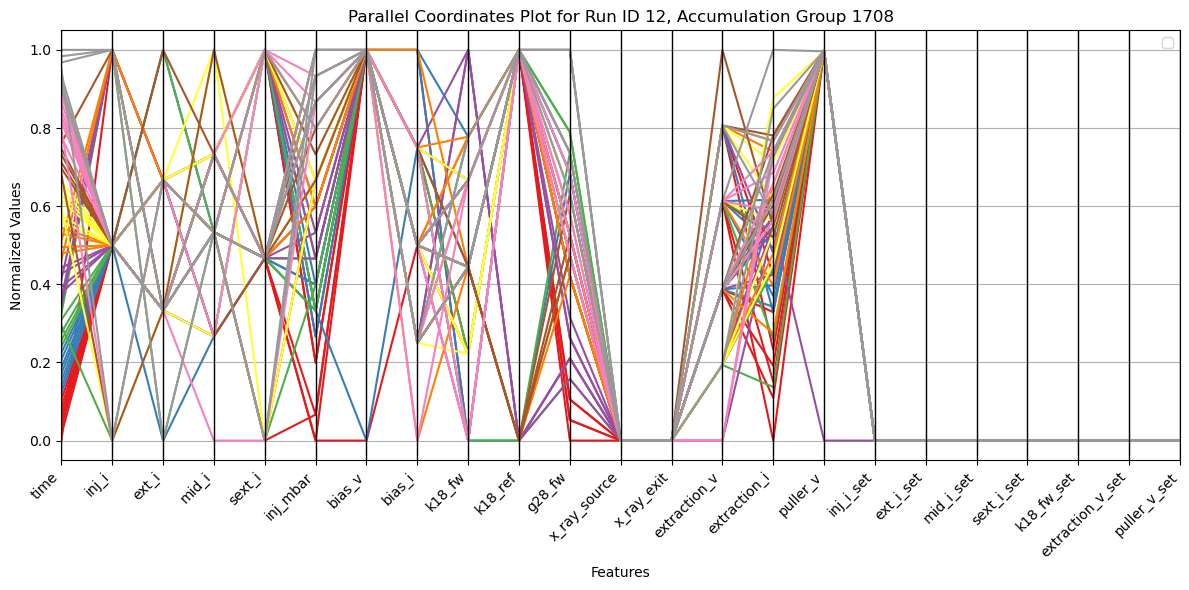

In [239]:
parallel_coords(raw_outlier_data, "puller_v_mean", "12", 1708)

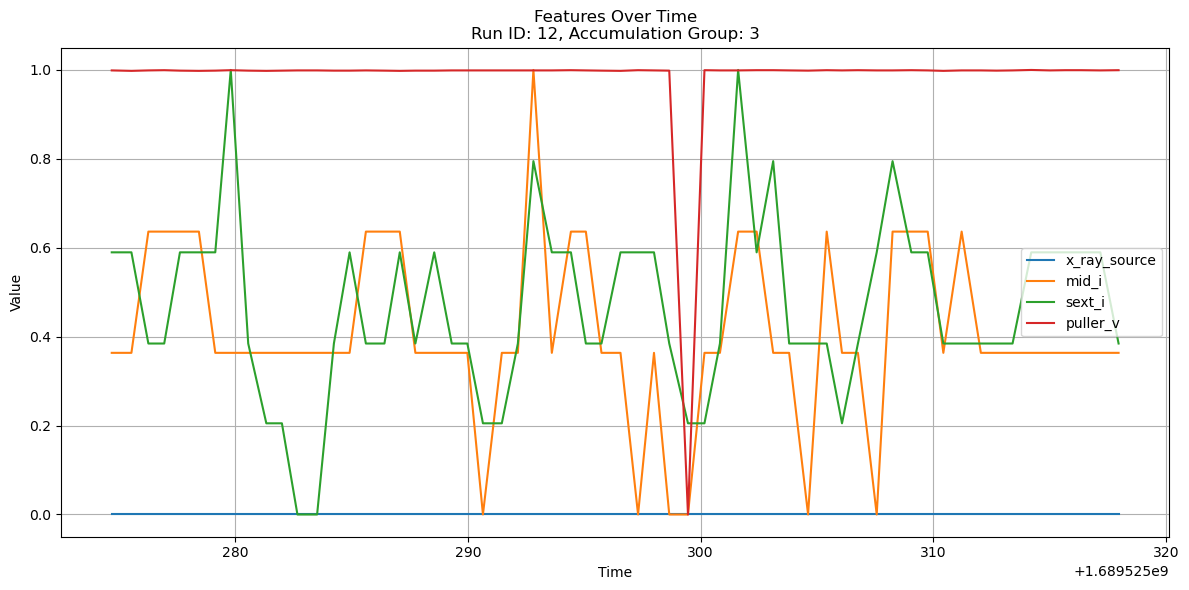

In [258]:
plot_features_over_time(raw_outlier_data, "puller_v_mean",
                        "12",
                        3,
                        ['x_ray_source', 'mid_i', 'sext_i', 'puller_v'])